In [2]:
import random
import numpy as np
import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import os.path
import pandas as pd
from sklearn import preprocessing

# User Inputs

In [3]:
sample_size = 512 #enter the size to which events will be up/downsampled

# designed for data in the following format:
# x[0] ,y[1] ,z[2] ,time[3], Amplitude[4]
TRACK_CLASS = False
dimension = 4 # desired dimension of data to be input
ISOTOPE = 'O16'

## Before proceeding, you must run the `convert-data.sh` script. This converts the desired .h5 data file into a NumPy array that will be used henceforth.

In [4]:
data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/' + ISOTOPE + '_w_event_keys.npy')
event_lens = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/' + ISOTOPE + '_event_lens.npy')
data[56437,0,-1] = 56437
assert data.shape == (event_lens.size, np.max(event_lens), 6), 'Array has incorrect shape'
assert len(np.unique(data[:,:,5])) == event_lens.size, 'Array has incorrect Event_ids'

# Random sample from NumPy array

In [6]:
# each instance will index according to the following 
# x, y, z, time, amplitude, number of tracks
new_array_name = ISOTOPE + '_size' + str(sample_size) + '_sampled'
new_data = np.zeros((event_lens.size, sample_size, 6), float) 
for i in tqdm.tqdm(range(event_lens.size)):
    ev_len = event_lens[i]    #length of event-- i.e. number of instances
    if i == 56437: # skipping the one empty event
        new_data[i,0,5] = 56437
        continue
    if ev_len > sample_size:
        random_points = np.random.choice(ev_len, sample_size, replace=False)  #choosing the random instances to sample
        count = 0
        for r in random_points:
            new_data[i,count,:] = data[i,r,:]
            count += 1
    else:
        new_data[i,:ev_len,:] = data[i,:ev_len,:]
        need = sample_size - ev_len
        random_points = np.random.choice(ev_len, need, replace= True if need > ev_len else False)         
        count = ev_len
        for r in random_points:
            new_data[i,count,:] = data[i,r,:]
            count += 1
    new_data[i,0,5] = data[i,0,5] # saving the event index
            
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/' + new_array_name, new_data) 

assert new_data.shape == (event_lens.size, sample_size, 6), 'Array has incorrect shape'
assert len(np.unique(new_data[:,:,5])) == event_lens.size, 'Array has incorrect number of events'
    

100%|██████████| 60796/60796 [00:22<00:00, 2704.01it/s]


In [ ]:
import numpy as np

def print_column_values(file_path):
    """Print values of the first column from the loaded data"""
    event_data = np.load(file_path)
    for n in range(len(event_data)):
        column_values = event_data[n, 0, :]
        print(f'Values of first column:\n{column_values}')

print_column_values('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/O16_size512_sampled.npy')


# Adding Labels

In [7]:
df = pd.read_csv('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/O16_labels.csv')
labels = np.array(df['Number of tracks'])
indices = np.array(df['Event number'])
length = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/O16_event_lens.npy')

types, distr = np.unique(labels, return_counts=True)
num_trash = 200 # number of 0-track events to be included in the set
num_two = 200 # number of 2-track events to be included in the set
print('Total: ', types, distr) # nans signify empty labels-- i.e. events yet to be labelled
size = distr[1] + np.sum(distr[3:-1]) + num_trash + num_two
dataset = np.zeros((size, sample_size, dimension + 3), float)#There will be seven element in our array, and the dimension is 4
count, trash, two = 0, 0, 0

for i in range(len(indices)):
    if not np.isnan(labels[i]): # ignoring empty labels
        ev_num = int(indices[i])
        if int(labels[i]) != 0 and int(labels[i]) != 2: # if not a 0-track or 2-track event
            dataset[count,:,:3] = new_data[ev_num,:,:3] # xyz
            if dimension == 4: 
                dataset[count,:,3] = new_data[ev_num,:,4]#q
            dataset[count,0,-3] = new_data[ev_num,0,-1] # event index
            dataset[count,0,-2] = labels[i] # number of tracks
            dataset[count,0,-1] = length[ev_num]# length of event
            count += 1
        elif int(labels[i]) == 0 and trash < num_trash:
            dataset[count,:,:3] = new_data[ev_num,:,:3] # xyz
            if dimension == 4: 
                dataset[count,:,3] = new_data[ev_num,:,4]#q
            dataset[count,0,-3] = new_data[ev_num,0,-1] # event index
            dataset[count,0,-2] = labels[i] # number of tracks
            dataset[count,0,-1] = length[ev_num]# length of event
            count += 1
            trash += 1
        elif int(labels[i]) == 2 and two < num_two:
            dataset[count,:,:3] = new_data[ev_num,:,:3] # xyz
            if dimension == 4: 
                dataset[count,:,3] = new_data[ev_num,:,4]#q
            dataset[count,0,-3] = new_data[ev_num,0,-1] # event index
            dataset[count,0,-2] = labels[i] # number of tracks
            dataset[count,0,-1] = length[ev_num]# length of event
            count += 1
            two += 1  
types, distr = np.unique(dataset[:,0,-2], return_counts=True)
print('Included in set: ', types, distr)
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/' + ISOTOPE + '_size' + str(sample_size), dataset)

Total:  [ 0.  1.  2.  3.  4.  5. nan] [662 140 382 476 215 583  12]
Included in set:  [0. 1. 2. 3. 4. 5.] [200 140 200 476 215 583]


# Classification

In [8]:
def simplify_class(label):
    if int(label) == 0 or int(label) == 1 or int(label) == 2:
        return 0
    elif int(label) == 3:
        return 1
    else: # 4 or 5
        return 2

dataset[:,0,-2] = list(map(simplify_class, dataset[:,0,-2]))
types, distr = np.unique(dataset[:,0,-2], return_counts=True)
print('After simplification: ', types, distr)
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/' + ISOTOPE + '_size' + str(sample_size), dataset)

After simplification:  [0. 1. 2.] [540 476 798]


In [9]:
def print_column_values(file_path):
    """Print values of the first column from the loaded data"""
    event_data = np.load(file_path)
    for n in range(len(event_data)):
        column_values = event_data[n, 0, :]
        print(f'Values of first column:\n{column_values}')

print_column_values('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/O16_size512.npy')

Values of first column:
[-24.54118347 -31.20534706 220.48       447.77502441   0.
   0.         542.        ]
Values of first column:
[  -7.36236525   -1.45075214 -105.248        50.23751068    1.
    0.           44.        ]
Values of first column:
[  -9.81648064    2.79990482 -169.28        695.55000305    2.
    0.          253.        ]
Values of first column:
[-26.99529648  69.46125793  -5.024       69.13750458   3.
   0.         491.        ]
Values of first column:
[ 269.95294189  -19.87026405 -138.656        66.82498932    4.
    0.          295.        ]
Values of first column:
[  34.35765076    2.79990482  727.168      1097.05001831    5.
    0.          666.        ]
Values of first column:
[-2.45413113e+00  2.40531883e+01  3.32800000e+00  3.74966121e+03
  6.00000000e+00  0.00000000e+00  2.21000000e+02]
Values of first column:
[ -29.44941711    5.70140886   11.68       3635.09999847    7.
    0.          110.        ]
Values of first column:
[-51.53646469 -41.05581284  64.5

# Scaling 

In [10]:
# values correspond to the x,y,z,charge index
values = [0,1,2,3] 
means_and_stds = []
min_max_scaler = preprocessing.MinMaxScaler(feature_range=(-1, 1))
dataset[:,:,3] = np.log(dataset[:,:,3]) # log scale charge
# standard scaling 
for n in values:
    mean = np.mean(dataset[:,:,n])
    std = np.std(dataset[:,:,n])
    means_and_stds.append([mean,std])
    dataset[:,:,n] = (dataset[:,:,n] - mean) / std
dataset[:,0,-1] = np.log(dataset[:,0,-1])
dataset[:,0,-1] = min_max_scaler.fit_transform(dataset[:,0,-1].reshape(-1, 1)).reshape(1,-1)

assert np.sum(np.isnan(dataset)) == 0, 'NaNs in dataset'
assert np.sum(np.isinf(dataset)) == 0, 'Infinities in dataset'

# Split into training, testing, and validation sets
Performs a 60-20-20 split, including events at random.

In [11]:
rand_shuffle = np.random.choice(len(dataset), len(dataset), replace = False)
name = ISOTOPE + '_size' + str(sample_size)

# 20-20 marking for test and validation
test_split = int(len(dataset) * .2)
val_split = int(len(dataset) * .4)

test = dataset[rand_shuffle[:test_split],:,:]
val = dataset[rand_shuffle[test_split:val_split],:,:]
train = dataset[rand_shuffle[val_split:],:,:]
print(len(dataset))
print(test.shape, val.shape, train.shape)

np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data_splits/' + ISOTOPE + '_size' + str(sample_size)+'_test', test)
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data_splits/' + ISOTOPE + '_size' + str(sample_size)+'_val', val)
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data_splits/' + ISOTOPE + '_size' + str(sample_size)+'_train', train)
assert len(np.unique(np.isnan(train[:,:,4]))) == 1, 'NaNs in dataset'
assert len(np.unique(np.isnan(val[:,:,4]))) == 1, 'NaNs in dataset'
assert len(np.unique(np.isnan(test[:,:,4]))) == 1, 'NaNs in dataset'

1814
(362, 512, 7) (363, 512, 7) (1089, 512, 7)


# Make Histogram

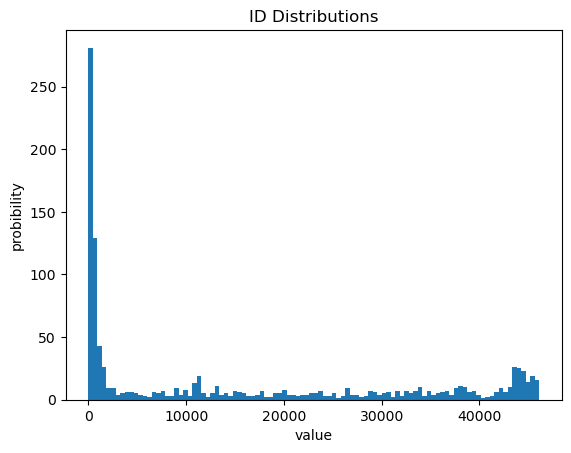

In [12]:
# Make histogram of values (either x,y,z,charge) from selected npy (train, val, test)
# Will need to change PLOT and DATA_SET_NAME to plot X-Y-Z-Q(charge) from training, val, or test
if dimension == 4:
    indices = ['X', 'Y', 'Z', 'A', 'ID', 'label', 'len']
else:
    indices = ['X', 'Y', 'Z', 'ID', 'label', 'len']
    
PLOT = 'ID'
DATA_SET_NAME = '_train'
index = indices.index(PLOT)

ds = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data_splits/' + ISOTOPE + '_size' + str(sample_size) + DATA_SET_NAME + '.npy')
if index >= dimension:
    info = ds[:,0,index].flatten()
else:
    info = ds[:,:,index].flatten()
plt.hist(info, bins=100)
plt.ylabel('probibility')
plt.xlabel('value')
plt.title(PLOT + ' Distributions')
plt.show()

# Voxelation Process

Normalizing coords into Unit Cube
This section takes the maximum and minimum data points from the original data file and normalizes it to fit the whole event in a unit cube. It writes the normalized data to a data file ending in _sampled_normal_.np

In [26]:
name = ISOTOPE + '_size' + str(sample_size)
data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + name + '.npy')

RANGES = {
            'MIN_X': -270.0,
            'MAX_X': 270.0,
            'MIN_Y': -270.0,
            'MAX_Y': 270.0,
            'MIN_Z': -185.0,
            'MAX_Z': 1155.0,
            'MIN_LOG_A': 0.0,
            'MAX_LOG_A': 8.60
        }


print("Maximums and minimums from the original data set:")
print(np.amax(data[:,:,0]), np.amax(data[:,:,1]), np.amax(data[:,:,2]))
print(np.amin(data[:,:,0]), np.amin(data[:,:,1]), np.amin(data[:,:,2]))

data[:,:,0] = data[:,:,0]+ abs(RANGES['MIN_X']) # WORKINGGGGBDFGDF ON IT 
data[:,:,0] = data[:,:,0]/ (RANGES['MAX_X'] + abs(RANGES['MIN_X'])) 
data[:,:,1] = data[:,:,1]+ abs(RANGES['MIN_Y'])
data[:,:,1] = data[:,:,1]/ (RANGES['MAX_Y'] + abs(RANGES['MIN_Y']))
data[:,:,2] = data[:,:,2]+ abs(RANGES['MIN_Z'])
data[:,:,2] = data[:,:,2]/ (RANGES['MAX_Z'] + abs(RANGES['MIN_Z']))

print()
print("Normalized maximums and minimums:")
print(np.amax(data[:,:,0]), np.amax(data[:,:,1]), np.amax(data[:,:,2]))
print(np.amin(data[:,:,0]), np.amin(data[:,:,1]), np.amin(data[:,:,2]))

new_array_name = ISOTOPE + '_size' + str(sample_size) + '_sampled_normal'
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + new_array_name, data)

FileNotFoundError: [Errno 2] No such file or directory: '/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/O16_size512.npy'

The following two code blocks print the data as a histogram and uses assertion statements to make sure that we are normalizing everything correctly. In other words, we want to make sure we didn't change any of the points relative to each other and also must ensure that no points lie outside of the unit cube bounds.

[0.45455336 0.62270587 0.82721569 ... 0.40910676 0.65906316 0.3772941 ]


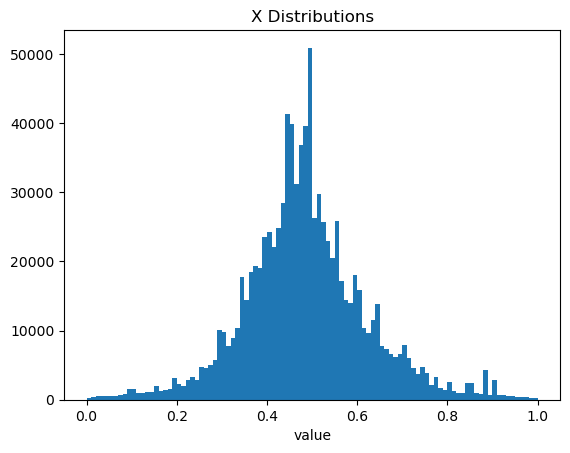

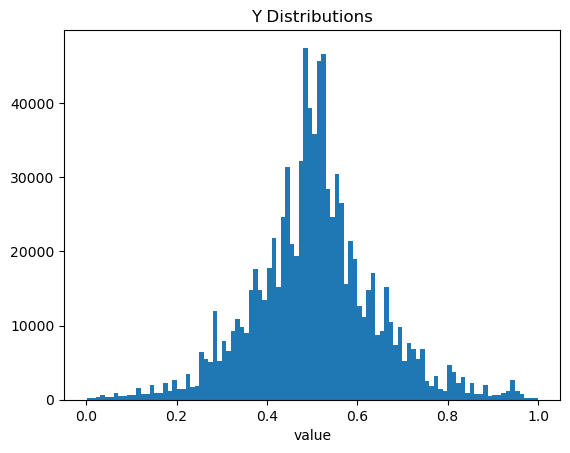

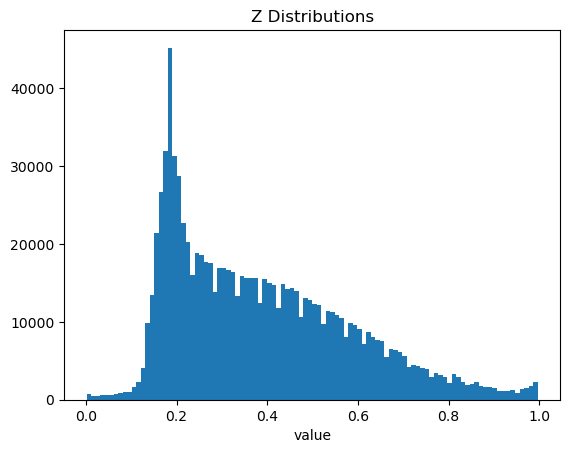

In [14]:
print(data[:,:,0].flatten())
plt.hist(data[:,:,0].flatten(), bins=100)
plt.xlabel('value')
plt.title('X Distributions')
plt.show()

plt.hist(data[:,:,1].flatten(), bins=100)
plt.xlabel('value')
plt.title('Y Distributions')
plt.show()

plt.hist(data[:,:,2].flatten(), bins=100)
plt.xlabel('value')
plt.title('Z Distributions')
plt.show()

### Assertion statements to check if coords are within unit cube

In [15]:
name = ISOTOPE + '_size' + str(sample_size) + '_sampled_normal'
data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/' + name + '.npy')

assert np.amin(data[:,:,0]) > 0, 'There are x-values that are negative'
assert np.amin(data[:,:,1]) > 0, 'There are y-values that are negative'
assert np.amin(data[:,:,2]) > 0, 'There are z-values that are negative'
assert np.amax(data[:,:,0]) < 1, 'There are x-values that are greater than 1'
assert np.amax(data[:,:,1]) < 1, 'There are y-values that are greater than 1'
assert np.amax(data[:,:,2]) < 1, 'There are z-values that are greater than 1'

# Voxelizing and Labeling
This section breaks the data into K voxels and uses a dictionary to create and store labels for each voxel. It also outputs two files: one that ends in _base_voxels.npy and another that ends in _voxelated.npy. The _base_voxels.npy file has all of the voxels plotted on top of each other and the _voxelated.npy is the original data with all of the points being assigned a voxel_id. For more information on these two files, see the voxel-data-exploration.ipynb notebook.

In [18]:
name = ISOTOPE + '_size' + str(sample_size) + '_sampled_normal' # Using normalized data
data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/data/' + name + '.npy')

K = 3 # Voxel resolution

new_data = np.zeros((len(data), sample_size, 6), float)

#Store voxel bounds in dict with keys being lists
#Structure: voxel[key] = [ [voxel_lower_bounds], [voxel_upper_bounds], voxel_id]
voxels = dict({})
i=0
for z in range(K):
    for y in range(K):
        for x in range(K):
            key = [x,y,z]
            value = []
            #Creating lower bound of voxel
            min_bounds = [-1,-1,-1]
            min_bounds[0] = (1/K)*x
            min_bounds[1] = (1/K)*y
            min_bounds[2] = (1/K)*z
            #Creating upper bound of voxel
            max_bounds = [-2,-2,-2]
            max_bounds[0] = (1/K) + (1/K)*x
            max_bounds[1] = (1/K) + (1/K)*y
            max_bounds[2] = (1/K) + (1/K)*z
            
            value.append(min_bounds)
            value.append(max_bounds)
            value.append(i)
            i += 1
            
            voxels[str(key)] = value
                  
# Identifying voxel id for each point and normalizing all points to be within [1/K,1/K,1/K]
# each instance will index according to the following 
# 0-x, 1-y, 2-z, 3-voxel id, 4-number of tracks, 5-event #

#indices: x, y, z, amplitude - 3, event index - 4, label - 5, event length - 6

for i in tqdm.tqdm(range(len(data))):
    for j in range(sample_size):
        
        #Finding Current Point's Voxel Key
        voxel_key = [-1,-1,-1]
        x_val = data[i,j,0]
        if x_val < (1/K):
            voxel_key[0] = 0
        elif x_val > ((1/K)*2):
            voxel_key[0] = 2
        else:
            voxel_key[0] = 1

        y_val = data[i,j,1]
        if y_val < (1/K):
            voxel_key[1] = 0
        elif y_val > ((1/K)*2):
            voxel_key[1] = 2
        else:
            voxel_key[1] = 1

        z_val = data[i,j,2]
        if z_val < (1/K):
            voxel_key[2] = 0
        elif z_val > ((1/K)*2):
            voxel_key[2] = 2
        else:
            voxel_key[2] = 1
        
        #Getting related voxel info
        lower_bound = voxels[str(voxel_key)][0]
        upper_bound = voxels[str(voxel_key)][1]
        voxel_num = voxels[str(voxel_key)][2]

        #Normalizing coords
        new_x = x_val-lower_bound[0]
        new_y = y_val-lower_bound[1]
        new_z = z_val-lower_bound[2]
        
        #Saving new voxel coords and id
        new_data[i,j,0] = new_x
        new_data[i,j,1] = new_y
        new_data[i,j,2] = new_z
        data[i,j,3] = voxel_num
        new_data[i,j,3] = voxel_num
        data[i,j,4] = data[i,j,5]
        new_data[i,j,4] = data[i,j,4]
        data[i,j,5] = str(i)
        new_data[i,j,5] = str(i)
        
        # 0-x, 1-y, 2-z, 3-voxel id, 4-number of tracks, 5-event #

        
        # before: x, y, z, amplitude - 3, event index - 4, label - 5, event length - 6

        #indices: x, y, z, voxel id - 3, amplitude - 4, label - 5, event length - 6
        
# new_data[:,:,0] represents the x values, new_data[:,:,1] is y, and so on. So the cell prints the maxs and mins of x,y, and z values
print(np.amax(new_data[:,:,0]), np.amax(new_data[:,:,1]), np.amax(new_data[:,:,2]))
print(np.amin(new_data[:,:,0]), np.amin(new_data[:,:,1]), np.amin(new_data[:,:,2]))
  
# Converting all voxel keys from list to corresponding voxel id
i = 0
for z in range(K):
    for y in range(K):
        for x in range(K):
            key = [x,y,z]
            voxels[i] = voxels[str(key)]
            del voxels[str(key)]
            i += 1
            
new_array_name1 = ISOTOPE + '_size' + str(sample_size) + '_base_voxels.npy'
new_array_name2 = ISOTOPE + '_size' + str(sample_size) + '_voxelated.npy'

np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + new_array_name1, new_data)
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + new_array_name2, data[:,:,:6]) # THIS is the file to use for incorporating unshuffled data in training set.

  8%|▊         | 143/1814 [00:00<00:04, 351.02it/s]

100%|██████████| 1814/1814 [00:05<00:00, 355.02it/s]


0.3332461886935765 0.3321806731047454 0.33284577114427866
8.714463975694445e-05 0.001152660228587963 0.00042786069651745695


In [19]:
voxels_np = np.zeros((K**3,2,3))
for i in range(K**3):
    min_bounds = voxels[i][0]
    max_bounds = voxels[i][1]
    voxels_np[i,0] = min_bounds
    voxels_np[i,1] = max_bounds

# print(voxels)
# print(voxels_np)
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/voxel_bounds.npy', voxels_np)

In [9]:
name1 = 'O16' + '_size' + str(512) + '_voxelated'
name2 = 'O16' + '_size' + str(512) + '_base_voxels'
voxel_data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + name1 + '.npy')
next_step_data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + name2 + '.npy')

print(voxel_data.shape, next_step_data.shape)

assert voxel_data.shape == (count, sample_size, 6), 'Voxelated Shape is incorrect'
assert next_step_data.shape == (count, sample_size, 6), 'Base Voxels Shape is incorrect'

(1814, 512, 6) (1814, 512, 6)


NameError: name 'count' is not defined

# Shuffling and Randomly Augmenting Voxels

In [27]:
name = ISOTOPE + '_size' + str(sample_size) + '_base_voxels'
name_unshuffled = ISOTOPE + '_size' + str(sample_size) + '_voxelated'
data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + name + '.npy')           # This is the data file with all of the voxels plotted on each other in one voxel. This makes the shuffling process easier
data_unshuffled = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + name_unshuffled + '.npy')           # This is the original data with the normalized, voxelized event

new_data = np.zeros((len(data), sample_size, 6), float)
for i in tqdm.tqdm(range(len(data))):
    
    #Gets a list of where each voxel is going to be shuffled
    #Repeats until each voxel is assigned an id other than its own
    flag = True
    while flag:
        permutations = []
        ids = []
        overlap = False
        for j in range(K**3):
            ids.append(j)
        for j in range(K**3):
            val = random.choice(ids)
            permutations.append(val)
            ids.remove(val)
        for j,x in enumerate(permutations):
            if j == x:
                overlap = True
        if overlap == False:
            flag = False
            
    #Moves each point to its new voxel        
    for j in range(sample_size):
        augment = 0
        #Optional random augmentaion (slightly changing xyz) for better generalization
        # rand = random.randint(1, 100)
        # if rand < 17:
            #Maximum point can shift is 1/20 of a unit cube
            #augment = (random.random())/20
            #if (rand%2) == 0:
                #augment = augment*-1
                  
        old_id = data[i,j,3]
        num_tracks = data[i,j,4]
        event_num = data[i,j,5]
        
        new_id = permutations[int(old_id)]
        new_min_bounds = voxels[new_id][0]
        new_x = data[i,j,0] + new_min_bounds[0] + augment
        new_y = data[i,j,1] + new_min_bounds[1] + augment
        new_z = data[i,j,2] + new_min_bounds[2] + augment
        
        #Doesn't include augment if causes point to move out of unit cube
        if (new_x < 0) or (new_x > 1):
            new_x = data[i,j,0] + new_min_bounds[0]
        if (new_y < 0) or (new_y > 1):
            new_y = data[i,j,1] + new_min_bounds[1]
        if (new_z < 0) or (new_z > 1):
            new_z = data[i,j,2] + new_min_bounds[2]
            
        new_data[i,j,0] = new_x
        new_data[i,j,1] = new_y
        new_data[i,j,2] = new_z
        new_data[i,j,3] = old_id
        new_data[i,j,4] = num_tracks
        new_data[i,j,5] = event_num
        
final_data = np.concatenate((data_unshuffled[:1000],new_data),axis=0) 
# Use the above line to change the proportions of unshuffled and shuffled data in the training set

print(final_data.shape)
# to confirm concatenation occured correctly

shuffled_data = ISOTOPE + '_size' + str(sample_size) + '_shuffled_voxels_only' # Only shuffled
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + shuffled_data, new_data)

new_array_name = ISOTOPE + '_size' + str(sample_size) + '_shuffled_voxels' # Includes unshuffled
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + new_array_name, final_data)

100%|██████████| 1814/1814 [00:03<00:00, 540.22it/s]


(2814, 512, 6)


### Assertion statements to check if coords are still within unit cube

In [6]:
ISOTOPE = 'O16'
import numpy as np

In [7]:
name = ISOTOPE + '_size' + str(512) + '_shuffled_voxels'
data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + name + '.npy')

assert np.amin(data[:,:,0]) > 0, 'There are x-values that are negative'
assert np.amin(data[:,:,1]) > 0, 'There are y-values that are negative'
assert np.amin(data[:,:,2]) > 0, 'There are z-values that are negative'
assert np.amax(data[:,:,0]) < 1, 'There are x-values that are greater than 1'
assert np.amax(data[:,:,1]) < 1, 'There are y-values that are greater than 1'
assert np.amax(data[:,:,2]) < 1, 'There are z-values that are greater than 1'

# Split Testing Set, Training Set, and Validation Set

In [29]:
# performs a 20-test 20-val 60-train split on all 4-track events
# generates an array of numbers as long as the length of the data to randomize the events 
name = ISOTOPE + '_size' + str(sample_size)
all_events = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + name + '_shuffled_voxels.npy')
rand_shuffle = np.random.choice(len(all_events), len(all_events), replace = False)


# 20-20 marking for test and validation
test_split = int(len(all_events) * .2)
val_split = int(len(all_events) * .4)


test_data =  all_events[rand_shuffle[:test_split],:,:]    #only saving the indices and number of tracks of the test events
val_data = all_events[rand_shuffle[test_split:val_split],:,:]
train_data = all_events[rand_shuffle[val_split:],:,:]


print(test_data.shape, val_data.shape, train_data.shape)
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test', test_data)
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'train', train_data)
np.save('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'val', val_data)

(562, 512, 6) (563, 512, 6) (1689, 512, 6)


# Making Test Sets

In [31]:
prev_data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + '_sampled.npy')
tr = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'train.npy')
va = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'val.npy')
te = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test.npy')

#works perfect if length of dataset is even, if odd, rounding may be off
#assert tr.shape == (np.ceil(len(prev_data) * .6) , sample_size, 4), 'Array has incorrect shape, check first for rounding error.'
#assert va.shape == (np.ceil(len(prev_data) * .2) , sample_size, 4), 'Array has incorrect shape, check first for rounding error.'
#assert te.shape == (np.ceil(len(prev_data) * .2) , sample_size, 4), 'Array has incorrect shape, check first for rounding error.'
print(len(prev_data))
print(tr.shape, va.shape, te.shape)
print(len(np.unique(tr[:,:,3])))

60796
(1689, 512, 6) (563, 512, 6) (562, 512, 6)
27


## Checking Test, Training, and Validation

In [32]:
check = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'train.npy')
check2 = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'val.npy')
check3 = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test.npy')


print(check.shape)
print(check2.shape)
print(check3.shape)
print('')

print(check[1][0][:])
print('')

print(len(np.unique(check[:,:,3])))
print(len(np.unique(check2[:,:,3])))
print(len(np.unique(check3[:,:,3])))

(1689, 512, 6)
(563, 512, 6)
(562, 512, 6)

[6.96557787e-02 5.36671356e-01 1.59241791e-01 5.00000000e+00
 2.00000000e+00 1.45100000e+03]

27
27
27


# Checking data sets


In [33]:
#load in test, val, and train np arrays
test = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test.npy')
train = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'train.npy')
val = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'val.npy')

In [34]:
#ASSERT
train = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'train.npy')
test = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test.npy')
val = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'val.npy')

assert np.sum(np.isnan(train)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(test)) == 0, 'NaNs in dataset'
assert np.sum(np.isnan(val)) == 0, 'NaNs in dataset'
assert np.sum(np.isinf(train)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(test)) == 0, 'Infinities in dataset'
assert np.sum(np.isinf(val)) == 0, 'Infinities in dataset'

# Make Histogram

In [36]:
CLASSIFICATION = 'Voxel'
class_type = CLASSIFICATION
PROJECTION = 'XYZ'
ISOTOPE = 'O16'

PROJ_TO_COLS = {'XYZ': [0,1,2]}

user_input = PROJ_TO_COLS[PROJECTION]
print(class_type)
print(user_input)

Voxel
[0, 1, 2]


2


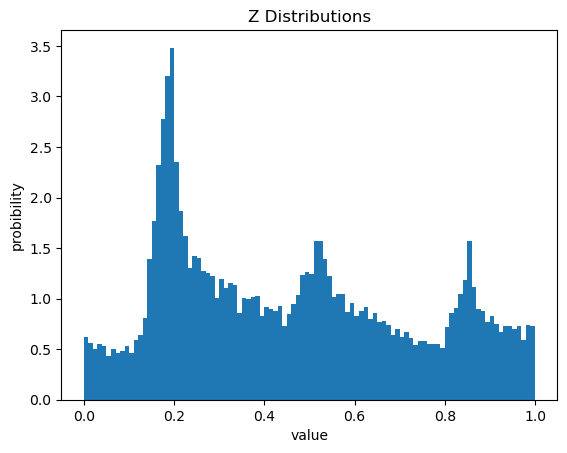

In [38]:
# Make histogram of values (either x,y,z,charge) from selected npy (train, val, test)
# Will need to change PLOT and DATA_SET_NAME to plot X-Y-Z-Q(charge) from training, val, or test
PLOT = 'Z'
DATA_SET_NAME = 'train'
index = PROJECTION.find(PLOT)
print(index)

if index != -1: #So that it is either X, Y or Z (0,1 or 2 indices)
    data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + DATA_SET_NAME + '.npy')
    info = data[:,:,index].flatten()
    plt.hist(info, density=True, bins=100)
    plt.ylabel('probibility')
    plt.xlabel('value')
    plt.title(PLOT + ' Distributions')
    plt.show()
    # plt.savefig('data/'+ '.png', bbox_inches = 'tight') # uncomment to save
else:
    print('Value to plot is invalid, change PLOT')

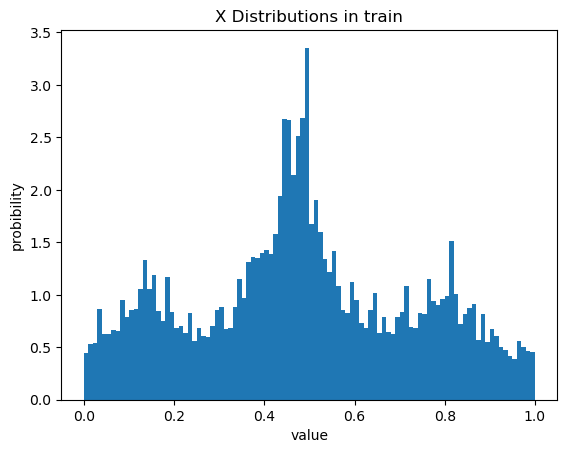

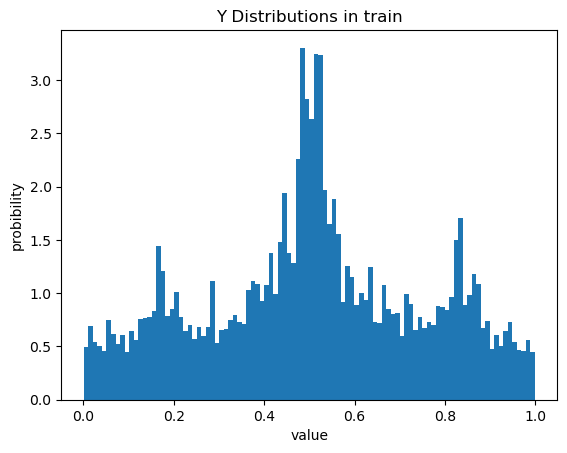

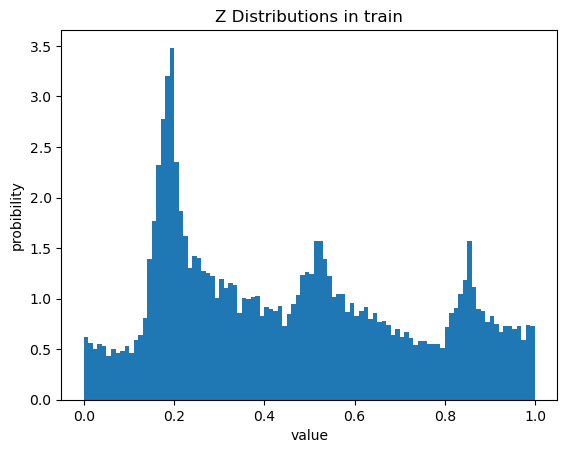

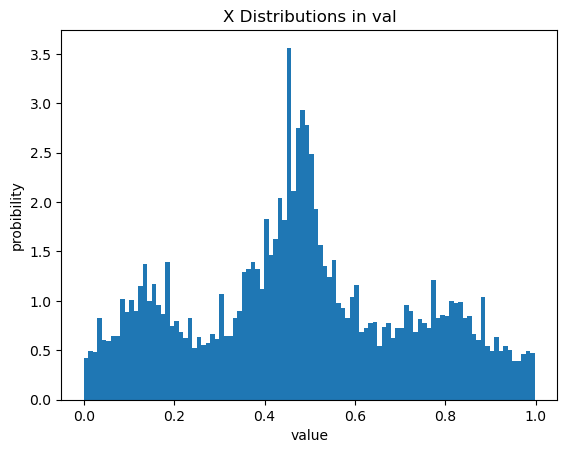

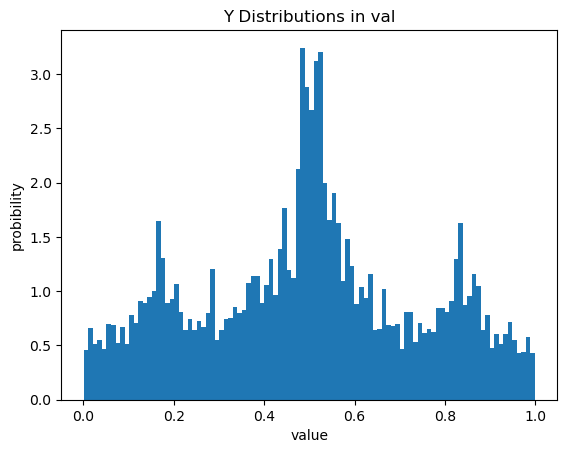

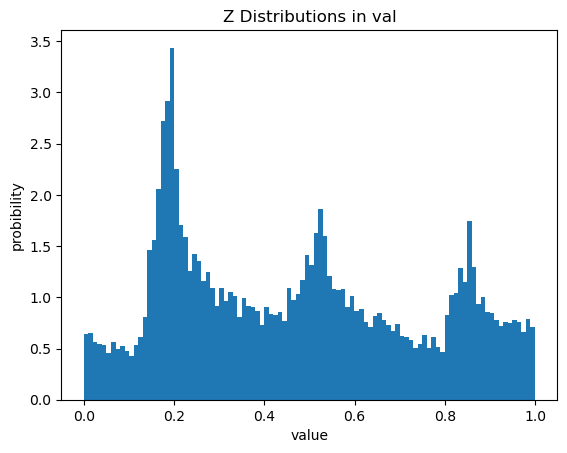

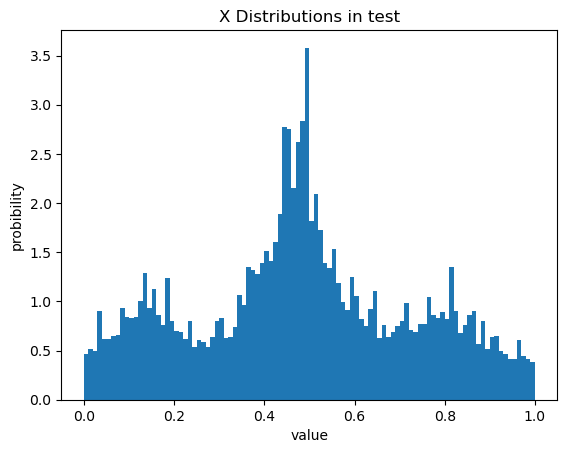

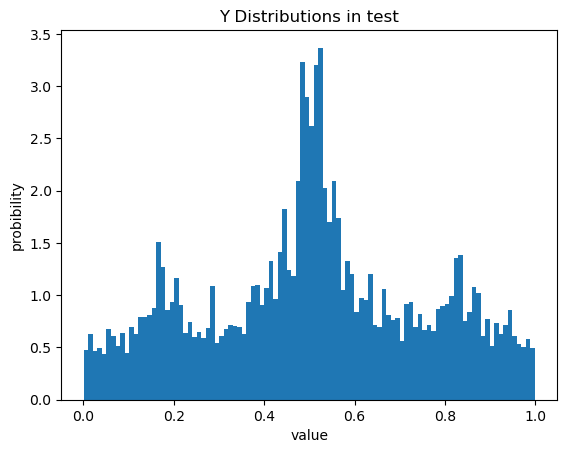

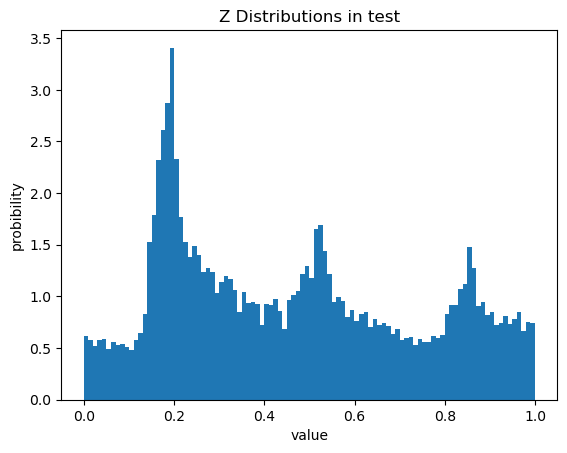

In [40]:
#plotting the x,y,and z distributions for training, validation, and test sets

CLASSIFICATION = 'MULTI-CLASS'
class_type = CLASSIFICATION
PROJECTION = 'XYZ'
ISOTOPE = 'O16'
PLOT = ['X', 'Y','Z']
DATA_SET_NAME = ['train','val','test']
for i in DATA_SET_NAME:
    for j in PLOT:
        index = PROJECTION.find(j)
        if index != -1:
            data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' +ISOTOPE+ '_size'+ str(sample_size) +i+ '.npy')
            info = data[:,:,index].flatten()
            plt.hist(info, density=True, bins=100)
            plt.ylabel('probibility')
            plt.xlabel('value')
            plt.title(j + ' Distributions in ' + i)
            plt.show()
            #plt.savefig('data/' +i+j+ '.png', bbox_inches = 'tight') 
        else:
            print('Value to plot is invalid, change PLOT')#

In [42]:
name = ISOTOPE + '_size' + str(sample_size) + '_voxelated'
data = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + name + '.npy')

for i in range(len(data)):
    for j in range(512):
        if data[i,j,4] == 5:
            print(data[i,j,5])
print(ISOTOPE)

O16


In [44]:
test = np.load('/home/DAVIDSON/dmkurdydyk/TPCNet/O16_expt_downstream/voxel_data/' + ISOTOPE + '_size' + str(sample_size) + 'test.npy')

event_nums = np.zeros((len(test),))
for i in range(len(test)):
    event_nums[i] = test[i,0,5]
    
